# 10. Đánh giá và so sánh mô hình

Notebook này thực hiện đánh giá cuối cùng các mô hình dự báo CPI nhóm Giao thông trên tập Test từ **01/2022 đến 12/2024**.

Các mô hình được so sánh gồm:

- Naive
- ElasticNet
- ARIMAX
- Ensemble

Các chỉ số đánh giá gồm **R², MAE, RMSE, MAPE và Directional Accuracy (DA)**.

In [9]:
import pandas as pd
import numpy as np

pred_df = pd.read_csv(
    "d:/HK3 - năm 3/Đồ Án/Code/vietnam-transportation-cpi-forecasting/data/processed/model_predictions.csv"
)

pred_df["MonthYear"] = pd.to_datetime(
    pred_df["MonthYear"]
).dt.to_period("M")

print("Kích thước:", pred_df.shape)

pred_df.head()

Kích thước: (36, 8)


,MonthYear,Actual,Naive_Pred,ElasticNet_Pred,ARIMAX_Pred,Naive_ElasticNet_Pred,Naive_ARIMAX_Pred,ElasticNet_ARIMAX_Pred
0,2022-01,1.18,-1.71,-1.453735,-1.559568,-1.559848,-1.623454,-1.505498
1,2022-02,2.35,1.18,2.129520,1.346587,1.736348,1.275840,1.746583
2,2022-03,4.80,2.35,1.945828,1.453298,2.113185,1.834115,1.704929
3,2022-04,-0.59,4.80,3.661777,2.729064,4.133086,3.608563,3.205582
4,2022-05,2.34,-0.59,-1.386979,-2.345179,-1.056971,-1.599778,-1.855640


## 2. Tính các chỉ số đánh giá

Các mô hình được đánh giá trên cùng tập Test 2022–2024 bằng các chỉ số:

- **MAE:** sai số tuyệt đối trung bình, càng thấp càng tốt.
- **RMSE:** nhấn mạnh các sai số lớn, càng thấp càng tốt.
- **R²:** mức độ giải thích biến động của CPI, càng cao càng tốt.
- **MAPE:** sai số phần trăm tuyệt đối trung bình.
- **DA:** tỷ lệ dự báo đúng chiều tăng hoặc giảm của CPI, càng cao càng tốt.

Do CPI có thể nhận giá trị gần 0 hoặc âm, MAPE có thể trở nên rất lớn và cần được diễn giải thận trọng.

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

model_cols = {
    "Naive": "Naive_Pred",
    "ElasticNet": "ElasticNet_Pred",
    "ARIMAX": "ARIMAX_Pred",
    "Naive_ElasticNet": "Naive_ElasticNet_Pred",
    "Naive_ARIMAX": "Naive_ARIMAX_Pred",
    "ElasticNet_ARIMAX": "ElasticNet_ARIMAX_Pred"
}

actual = pred_df["Actual"]

evaluation_results = []

for model_name, pred_col in model_cols.items():

    pred = pred_df[pred_col]

    # MAE
    mae = mean_absolute_error(
        actual,
        pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    # R²
    r2 = r2_score(
        actual,
        pred
    )

    # MAPE
    # Bỏ đúng các quan sát Actual = 0 để tránh chia cho 0
    non_zero = actual != 0

    mape = (
        np.mean(
            np.abs(
                (actual[non_zero] - pred[non_zero])
                / actual[non_zero]
            )
        ) * 100
    )

    # Directional Accuracy
    da = (
        np.mean(
            np.sign(actual) == np.sign(pred)
        ) * 100
    )

    evaluation_results.append({
        "Model": model_name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "DA (%)": da
    })

evaluation_df = (
    pd.DataFrame(evaluation_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

evaluation_df.round(4)

,Model,R2,MAE,RMSE,MAPE (%),DA (%)
0,ElasticNet_ARIMAX,-0.0690,1.9453,2.3332,440.1936,47.2222
1,ElasticNet,-0.0730,1.9421,2.3375,430.8424,50.0000
2,ARIMAX,-0.1205,2.0428,2.3887,544.9922,47.2222
3,Naive_ARIMAX,-0.2542,2.2034,2.5273,662.1324,38.8889
4,Naive_ElasticNet,-0.2580,2.1845,2.5311,657.5650,44.4444
5,Naive,-0.7292,2.5511,2.9675,981.8441,41.6667


### Nhận xét

Trên tập Test 2022–2024, **ElasticNet + ARIMAX** đạt RMSE thấp nhất (**2.3332**), trong khi **ElasticNet** đạt MAE thấp nhất (**1.9421**) và Directional Accuracy cao nhất (**50%**). Hai cấu hình Ensemble có thành phần Naive cho kết quả kém hơn, cho thấy việc kết hợp với Naive không giúp cải thiện khả năng dự báo.

Tất cả mô hình đều có R² âm, cho thấy khả năng giải thích các biến động ngoài mẫu còn hạn chế. MAPE cao do CPI có nhiều giá trị gần 0, vì vậy RMSE và MAE được ưu tiên khi đánh giá mô hình.


In [11]:
evaluation_df.to_csv(
    "d:/HK3 - năm 3/Đồ Án/Code/vietnam-transportation-cpi-forecasting/data/processed/model_evaluation_metrics.csv",
    index=False
)

## 3. So sánh kết quả dự báo theo thời gian

Biểu đồ dưới đây so sánh CPI thực tế với kết quả dự báo của các mô hình trên tập Test 2022–2024, nhằm đánh giá trực quan khả năng bám sát biến động thực tế của từng mô hình.

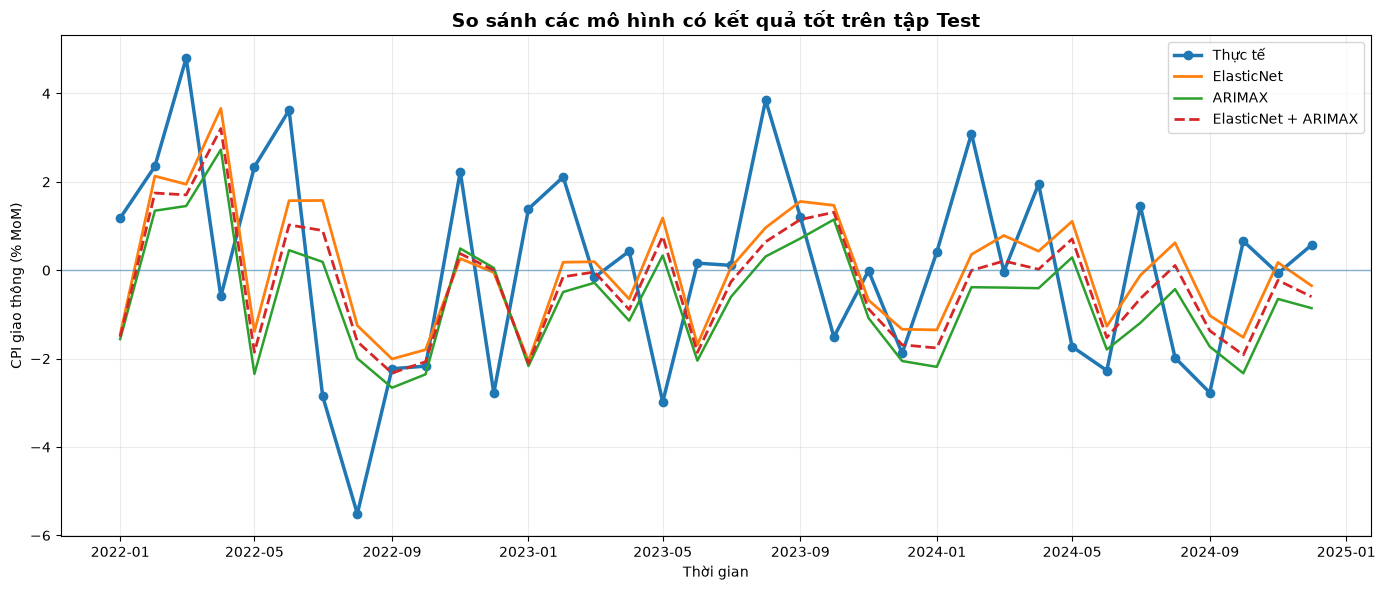

In [12]:
import matplotlib.pyplot as plt

dates = pred_df["MonthYear"].dt.to_timestamp()

plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    pred_df["Actual"],
    marker="o",
    linewidth=2.5,
    label="Thực tế"
)

plt.plot(
    dates,
    pred_df["ElasticNet_Pred"],
    linewidth=2,
    label="ElasticNet"
)

plt.plot(
    dates,
    pred_df["ARIMAX_Pred"],
    linewidth=1.8,
    label="ARIMAX"
)

plt.plot(
    dates,
    pred_df["ElasticNet_ARIMAX_Pred"],
    linestyle="--",
    linewidth=2,
    label="ElasticNet + ARIMAX"
)

plt.title(
    "So sánh các mô hình có kết quả tốt trên tập Test",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Thời gian")
plt.ylabel("CPI giao thông (% MoM)")

plt.axhline(y=0, linewidth=1, alpha=0.5)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Nhận xét

Biểu đồ cho thấy các mô hình nhìn chung phản ánh được xu hướng biến động của CPI giao thông, tuy nhiên khả năng dự báo tại các thời điểm biến động mạnh vẫn còn hạn chế.

Mô hình **Naive** phản ứng chậm khi CPI đảo chiều do chỉ sử dụng giá trị của tháng trước làm dự báo. Hai mô hình **ElasticNet** và **ElasticNet + ARIMAX** có đường dự báo khá gần nhau và bám sát CPI thực tế tốt hơn các mô hình còn lại. Trong khi đó, **ARIMAX** cho dự báo tương đối ổn định nhưng vẫn có xu hướng đánh giá thấp mức độ biến động tại một số thời điểm.

Hai cấu hình Ensemble có thành phần Naive là **Naive + ElasticNet** và **Naive + ARIMAX** không cải thiện kết quả rõ rệt, phù hợp với kết quả RMSE trên tập Test.

Nhìn chung, kết quả trực quan phù hợp với đánh giá định lượng, trong đó **ElasticNet + ARIMAX đạt RMSE thấp nhất**, còn **ElasticNet đạt MAE thấp nhất và Directional Accuracy cao nhất** trên tập Test 2022–2024.

Sai số lớn tập trung nhiều ở các giai đoạn CPI biến động mạnh. Do tập Development chỉ kéo dài đến năm 2021, các mô hình chưa được huấn luyện trực tiếp trên những biến động bất thường xuất hiện trong giai đoạn Test. Ngoài ra, việc sử dụng nhiều biến ở độ trễ 1 tháng cũng có thể làm mô hình phản ứng chậm trước các thay đổi đột ngột.